In [4]:
#Titanic Kaggle

Se importa la librería pandas y se carga el dataset "train.csv" en un DataFrame llamado datos, que será utilizado para el análisis y modelado.

In [5]:
import pandas as pd
datos = pd.read_csv("train.csv")

Se muestran las primeras filas del dataset para visualizar su estructura, columnas y algunos valores iniciales.

In [6]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Se generan estadísticas descriptivas de las variables numéricas del dataset, como media, desviación estándar, valores mínimos y máximos.

In [7]:
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Se importa la librería seaborn y se crea un gráfico de conteo para mostrar cuántos pasajeros sobrevivieron y cuántos no.

<Axes: xlabel='Survived', ylabel='count'>

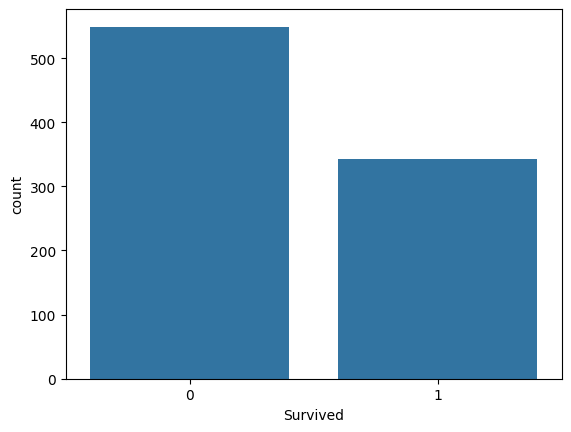

In [8]:
import seaborn as sb
sb.countplot(x="Survived", data=datos)

Se crea un gráfico de conteo de la variable "Survived", separado por sexo, para observar la relación entre el género y la supervivencia.

<Axes: xlabel='Survived', ylabel='count'>

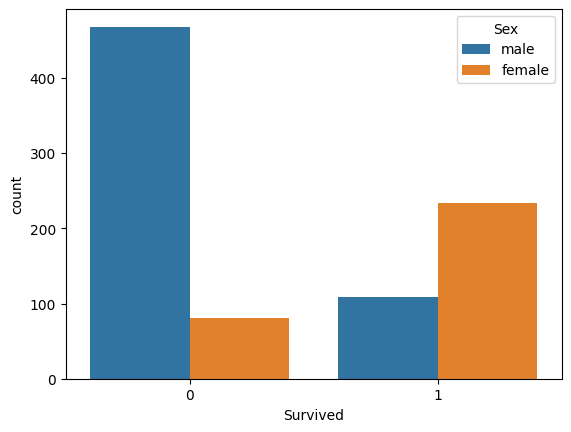

In [9]:
sb.countplot(x="Survived", data=datos, hue="Sex")

Se identifican los valores faltantes en el dataset, mostrando qué datos están vacíos en cada columna.

In [10]:
datos.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


Se cuenta la cantidad de valores faltantes por cada columna del dataset.

In [11]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Se crea una gráfica de distribución de la variable "Age" para observar cómo se distribuyen las edades de los pasajeros.

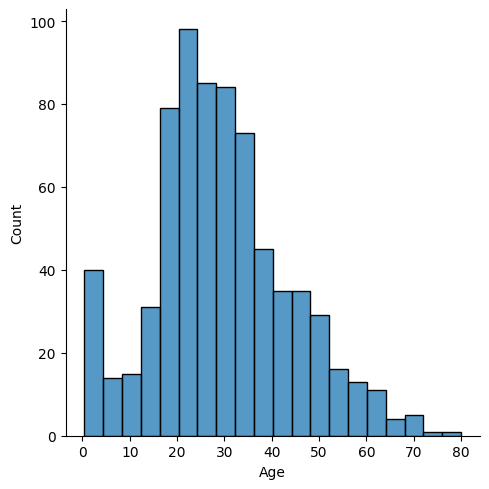

In [12]:
sb.displot(x="Age", data=datos)

Se accede a la columna "Age" del dataset para visualizar sus valores.

In [13]:
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


Se calcula el promedio de la edad de los pasajeros en el dataset.

In [14]:
datos["Age"].mean()

np.float64(29.69911764705882)

Se reemplazan los valores faltantes de la columna "Age" por el promedio de la edad.

In [15]:
datos["Age"].fillna(datos["Age"].mean())

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


Se rellenan los valores faltantes de la columna "Age" con el promedio y se actualiza el dataset con esos cambios.

In [16]:
datos["Age"] = datos["Age"].fillna(datos["Age"].mean())

Se vuelve a mostrar la columna "Age" para verificar que los valores faltantes han sido reemplazados.

In [17]:
datos["Age"]

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


Se revisa nuevamente la cantidad de valores faltantes por columna para verificar los cambios realizados.

In [18]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Se elimina la columna "Cabin" del dataset debido a la gran cantidad de valores faltantes.

In [19]:
datos= datos.drop(["Cabin"], axis=1)

Se cuentan las ocurrencias de cada valor en la columna "Embarked" para identificar el más frecuente.

In [20]:
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


Se eliminan las filas que aún contienen valores faltantes en el dataset.

In [21]:
datos = datos.dropna()

Se muestran las primeras filas del dataset después de la limpieza para verificar los cambios realizados.

In [22]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Se eliminan las columnas "Name", "PassengerId" y "Ticket" ya que no aportan valor directo al modelo de predicción.

In [23]:
datos = datos.drop(["Name", "PassengerId", "Ticket"], axis=1)

Se convierten los valores de la columna "Sex" en variables numéricas mediante variables dummy.

In [24]:
dummies_sex = pd.get_dummies(datos["Sex"], drop_first=True)

Se agregan las variables dummy de "Sex" al dataset y se elimina la columna original.

In [25]:
datos = datos.join(dummies_sex)
datos = datos.drop(["Sex"], axis=1)

Se crea un gráfico de conteo de la variable "Survived", separado por el puerto de embarque, para observar su relación con la supervivencia.

<Axes: xlabel='Survived', ylabel='count'>

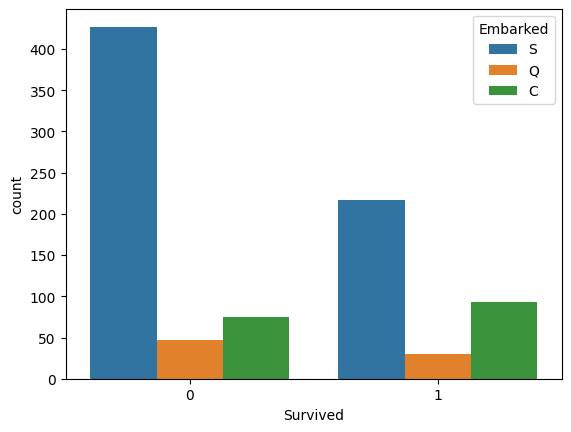

In [26]:
sb.countplot(x="Survived", data=datos, hue="Embarked")

Se convierten los valores de la columna "Embarked" en variables numéricas mediante variables dummy.

In [27]:
dummies_embarked = pd.get_dummies(datos["Embarked"], drop_first=True)

Se agregan las variables dummy de "Embarked" al dataset y se elimina la columna original.

In [28]:
datos = datos.join(dummies_embarked)
datos = datos.drop(["Embarked"], axis=1)

Se genera un mapa de calor de la correlación entre variables para identificar relaciones entre ellas.

<Axes: >

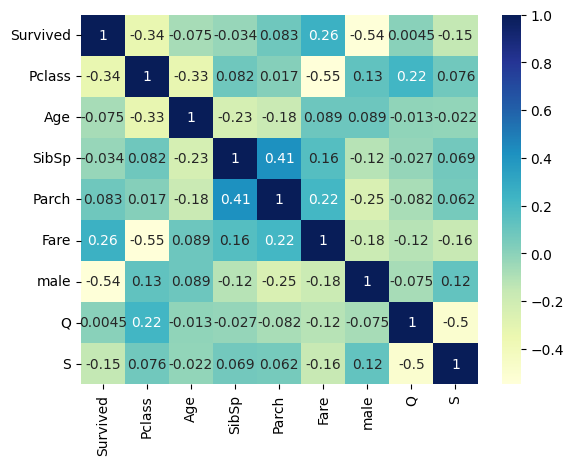

In [29]:
sb.heatmap(datos.corr(), annot=True, cmap="YlGnBu")

Se crea un gráfico de conteo de la variable "Survived", separado por la clase del pasajero, para analizar su relación con la supervivencia.

<Axes: xlabel='Survived', ylabel='count'>

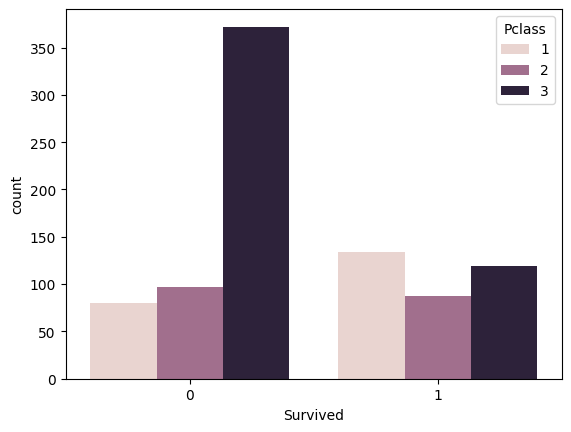

In [30]:
sb.countplot(x="Survived", data=datos, hue="Pclass")

Se separan los datos en variables independientes (X) y la variable objetivo (y), donde "Survived" es lo que se quiere predecir.

In [31]:
X = datos.drop(["Survived"], axis=1)
y = datos["Survived"]

Se dividen los datos en conjuntos de entrenamiento y prueba, utilizando el 80% para entrenar el modelo y el 20% para evaluarlo.

In [32]:
from sklearn.model_selection import train_test_split

X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=.2)

In [33]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth=50)
modelo.fit(X_ent, y_ent)
predicciones = modelo.predict(X_pru)

In [34]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru, predicciones)

0.7921348314606742

In [35]:
from sklearn.tree import DecisionTreeClassifier

resultados = []
for i in range(1,15):
  modelo = DecisionTreeClassifier(max_depth=i)
  modelo.fit(X_ent, y_ent)
  predicciones = modelo.predict(X_pru)
  exactitud = accuracy_score(y_pru, predicciones)
  print(f"Resultado par {i}: {exactitud}")
  resultados.append(exactitud)

Resultado par 1: 0.8033707865168539
Resultado par 2: 0.7808988764044944
Resultado par 3: 0.8258426966292135
Resultado par 4: 0.8314606741573034
Resultado par 5: 0.8314606741573034
Resultado par 6: 0.8426966292134831
Resultado par 7: 0.8370786516853933
Resultado par 8: 0.8314606741573034
Resultado par 9: 0.8089887640449438
Resultado par 10: 0.8146067415730337
Resultado par 11: 0.797752808988764
Resultado par 12: 0.8033707865168539
Resultado par 13: 0.7808988764044944
Resultado par 14: 0.7808988764044944


<Axes: >

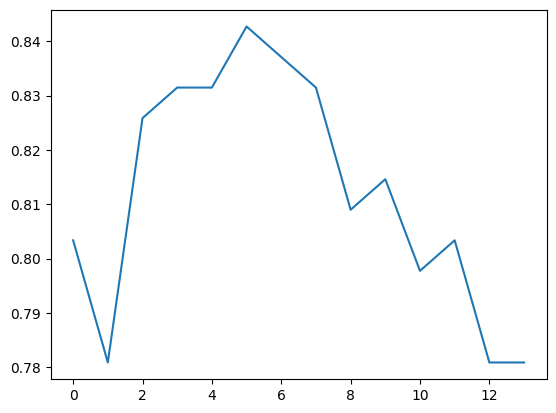

In [36]:
sb.lineplot(data=resultados)

In [38]:
modelo= DecisionTreeClassifier(max_depth=8)
modelo.fit(X_ent, y_ent)
predicciones= modelo.predict(X_pru)
exactitud = accuracy_score(y_pru, predicciones)
resultados.append(exactitud)

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       111
           1       0.84      0.72      0.77        67

    accuracy                           0.84       178
   macro avg       0.84      0.82      0.83       178
weighted avg       0.84      0.84      0.84       178



In [40]:
from sklearn.metrics import confusion_matrix
pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["pred: No", "Pred: Si"], index=["Real: No", "Real: Si"])

,pred: No,Pred: Si
Real: No,102,9
Real: Si,19,48


In [41]:
X_ent.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male', 'Q', 'S'], dtype='object')

[Text(0.44642857142857145, 0.9444444444444444, 'male <= 0.5\ngini = 0.473\nsamples = 711\nvalue = [438, 273]\nclass = Murio'),
 Text(0.25956632653061223, 0.8333333333333334, 'Pclass <= 2.5\ngini = 0.385\nsamples = 246\nvalue = [64, 182]\nclass = vivio'),
 Text(0.35299744897959184, 0.8888888888888888, 'True  '),
 Text(0.1211734693877551, 0.7222222222222222, 'Fare <= 28.856\ngini = 0.086\nsamples = 133\nvalue = [6, 127]\nclass = vivio'),
 Text(0.09948979591836735, 0.6111111111111112, 'Fare <= 28.231\ngini = 0.168\nsamples = 54\nvalue = [5, 49]\nclass = vivio'),
 Text(0.08928571428571429, 0.5, 'Age <= 56.0\ngini = 0.14\nsamples = 53\nvalue = [4, 49]\nclass = vivio'),
 Text(0.05612244897959184, 0.3888888888888889, 'SibSp <= 0.5\ngini = 0.111\nsamples = 51\nvalue = [3, 48]\nclass = vivio'),
 Text(0.02040816326530612, 0.2777777777777778, 'Age <= 37.0\ngini = 0.056\nsamples = 35\nvalue = [1, 34]\nclass = vivio'),
 Text(0.01020408163265306, 0.16666666666666666, 'gini = 0.0\nsamples = 24\nvalue

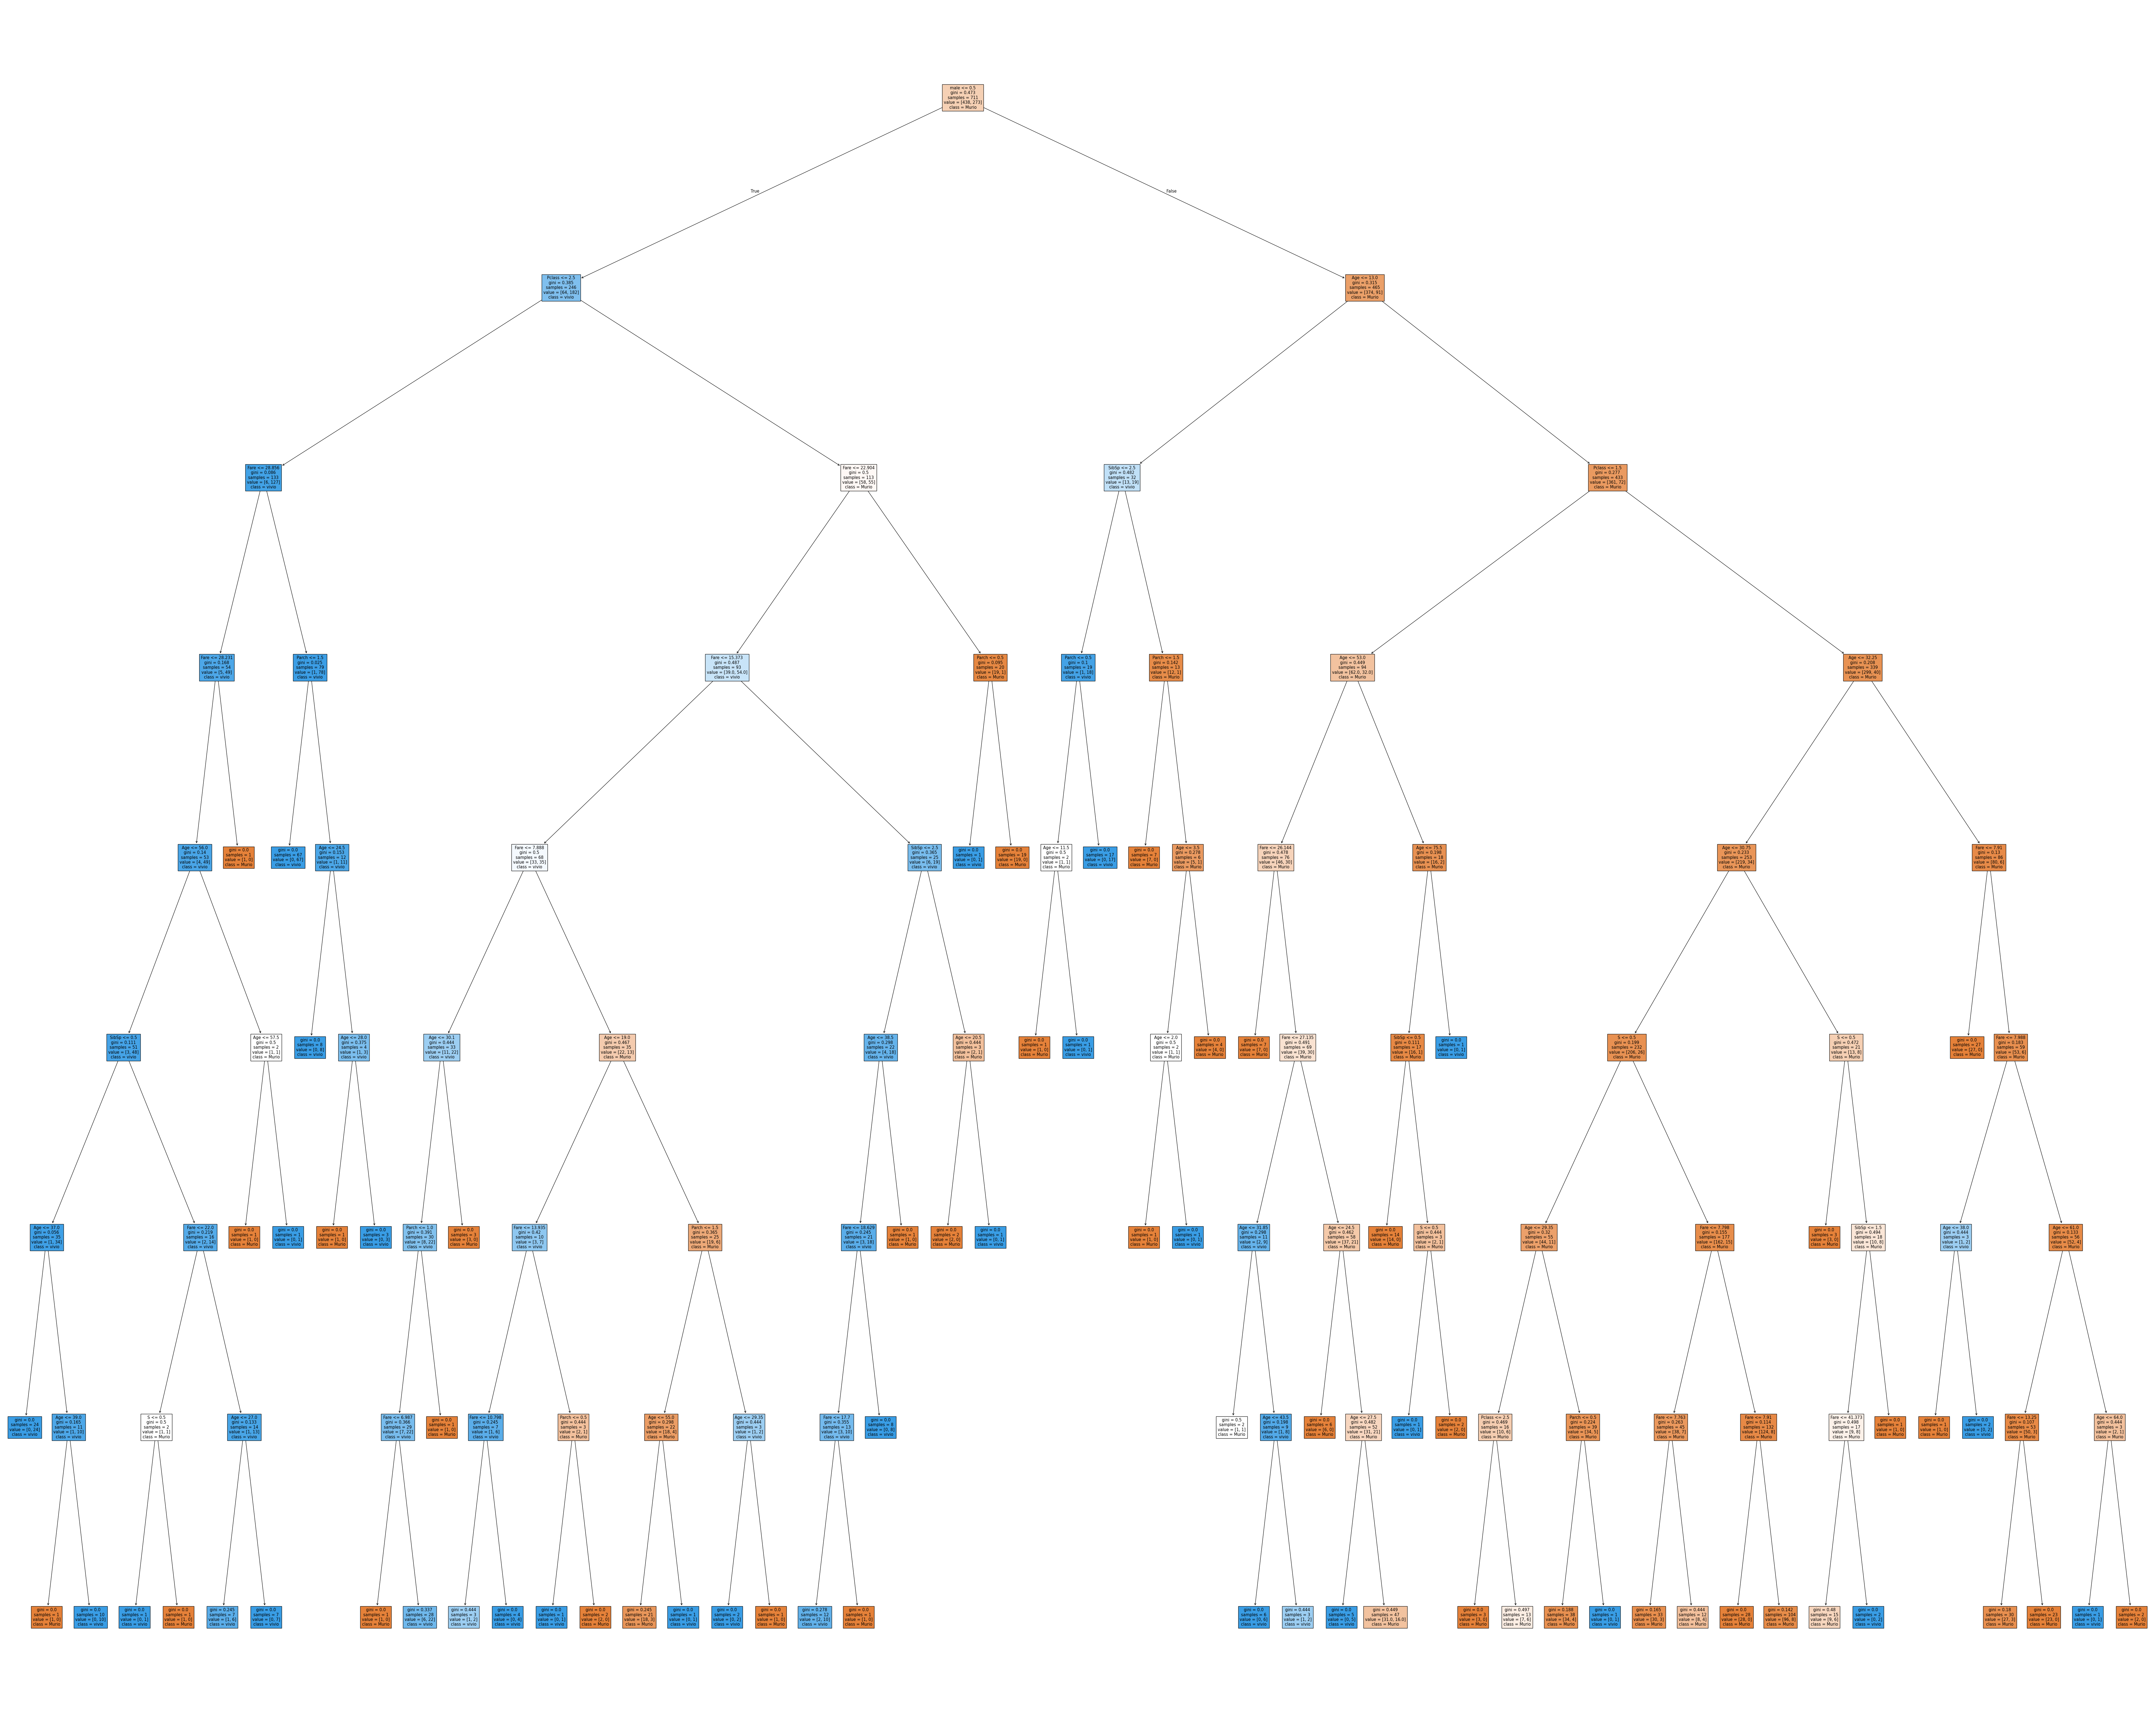

In [44]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(100,80))
plot_tree(
    modelo,
    feature_names=X_ent.columns,
    class_names=["Murio", "vivio"],
    filled=True
)

Se crea y entrena un modelo de regresión logística utilizando los datos de entrenamiento.

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_ent, y_ent)

LogisticRegression(max_iter=1000)

Se generan predicciones del modelo utilizando los datos de prueba.

In [ ]:
predicciones = modelo.predict(X_pru)

Se calcula la exactitud del modelo comparando las predicciones con los valores reales del conjunto de prueba.

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru, predicciones)

0.7752808988764045

Se genera un reporte de clasificación que muestra métricas como precisión, recall y F1-score para evaluar el rendimiento del modelo.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.83      0.80      0.82       112
           1       0.69      0.73      0.71        66

    accuracy                           0.78       178
   macro avg       0.76      0.77      0.76       178
weighted avg       0.78      0.78      0.78       178



Se calcula la matriz de confusión para comparar las predicciones del modelo con los valores reales y observar aciertos y errores.

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_pru, predicciones)

array([[90, 22],
       [18, 48]])

Se presenta la matriz de confusión en formato de tabla para facilitar la interpretación de los resultados del modelo.

In [ ]:
pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["pred: No", "Pred: Si"], index=["Real: No", "Real: Si"])

,pred: No,Pred: Si
Real: No,90,22
Real: Si,18,48


Se muestran las primeras filas de las variables independientes (X) para verificar los datos utilizados por el modelo.

In [ ]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


Se crea un ejemplo de una nueva persona con ciertas características y se utiliza el modelo para predecir si sobreviviría o no.

In [ ]:
nueva_persona = [3, 35, 0, 0, 10, 1, 0, 0]
prediccion = modelo.predict([nueva_persona])
if prediccion[0] == 1:
  print("Sobreviviste")
else:
  print("No sobreviviste")

No sobreviviste


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
